# Homework (Week 3) -- Biometrics (20 points)

In this homework we train Biometrics Verification model and use some features to increase quality:
1) Train ECAPA-TDNN (10 points)
2) Any contrastive loss (10 points)

Link to download dataset: https://disk.yandex.ru/d/lyhtieYbxQOYqw

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import tqdm.notebook as tqdm
import urllib

import dataset

from IPython.display import clear_output

%matplotlib inline

In [2]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/lyhtieYbxQOYqw'
final_url = base_url + urllib.parse.urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']
# !wget -O voxceleb.tar.gz "{download_url}"
# !tar -xf voxceleb.tar.gz

### Some model train example

In [3]:
DEVICE = 'cuda' # "cpu" for cpu, also you can use "cuda" for gpu and "mps" for apple silicon
DATADIR = './'
FEATS = 80
LOADER_WORKERS = 0

In [4]:
transform = torchaudio.transforms.MFCC(n_mfcc=FEATS) # You can try some other transformations here
trainset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_train'), transform)
testset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_test'), transform)
test_targets = pd.read_csv(os.path.join(DATADIR, 'target.csv')).values.tolist()

/opt/conda/lib/python3.11/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


### Models

In [5]:
class Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden: int, kernel: int = 7, sride: int = 2):
        super().__init__()
        self._emb = nn.Sequential(
            nn.Conv1d(input_shape, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.AdaptiveMaxPool1d(1),
        )
        self._final = nn.Sequential(
            nn.Linear(hidden, output_shape),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        emb = self._emb(X).squeeze(2)
        return self._final(emb), emb

### Metrics

Cosine similarity:
$CS(a, b) = \frac{<a, b>}{\|a\| \|b\|}$

In [6]:
def cosine_similarity(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    return np.dot(a, b) / np.linalg.norm(a) / np.linalg.norm(b)

Here is O(N log N) algorithm for find best_eer:
1) Sort prediction by probability
2) Going through items and recalculating far and frr

In [7]:
def best_eer(data):
    full = sorted(data, key=lambda x: (x[0], -x[1]))
    pos = len([item for item in full if item[1] == 1])
    neg = len(full) - pos
    cur_pos = pos
    cur_neg = 0
    best_eer = 1
    for _, label in full:
        if label == 1:
            cur_pos -= 1
        else:
            cur_neg += 1
        cur_eer = max((pos - cur_pos) / pos, (neg - cur_neg) / neg)
        best_eer = min(best_eer, cur_eer)
    return best_eer

### Train

In [8]:
def train_stage(model, opt, scheduler, batch_size: int = 256):
    loader = torch_data.DataLoader(
        trainset,
        shuffle=True,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    loss_sum = 0.0
    batches = 0
    
    for X, Y, _ in tqdm.tqdm(loader):
        logits, _ = model.forward(X.to(DEVICE))
        loss = F.nll_loss(logits, Y.to(DEVICE))
        loss_sum += loss.item()
        batches += 1
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        # --- ADDED: Scheduler Step ---
        scheduler.step() 
        # ------------------------------
        
    return loss_sum / batches

In [9]:
def calc_eval_score(model: nn.Module, batch_size: int = 256):
    loader = torch_data.DataLoader(
        testset,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    items = {}
    target_scores = []
    with torch.no_grad():
        for X, _, pathes in tqdm.tqdm(loader):
            _, embds = model.forward(X.to(DEVICE))
            embds = embds.cpu().data.numpy().reshape(X.shape[0], -1)
            for embd, path in zip(embds, pathes):
                items[path] = embd
    for item1, item2, target in test_targets:
        target_scores.append((cosine_similarity(items[item1], items[item2]), target))
    return best_eer(target_scores)

In [10]:
from transformers import get_cosine_schedule_with_warmup

def train(
    model: nn.Module,
    opt,
    batch_size: int = 256,
    epochs: int = 10,
    train_fun = train_stage,
    warmup_ratio: float = 0.1, 
):
    train_losses = []
    eval_scores = []

    num_batches = len(trainset) // batch_size
    total_steps = num_batches * epochs
    num_warmup_steps = int(total_steps * warmup_ratio)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=opt,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=total_steps
    )

    for epoch in range(epochs):
        model.train()
        # Pass scheduler into train_fun
        train_losses.append(train_fun(model, opt, scheduler, batch_size=batch_size))
        model.eval()
        eval_scores.append(calc_eval_score(model, batch_size=batch_size))
        clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train CE loss')
        axis[1].plot(np.arange(1, epoch + 2), eval_scores, label='eval')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='EER')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}. Train loss {train_losses[-1]}. Eval score {eval_scores[-1]}')

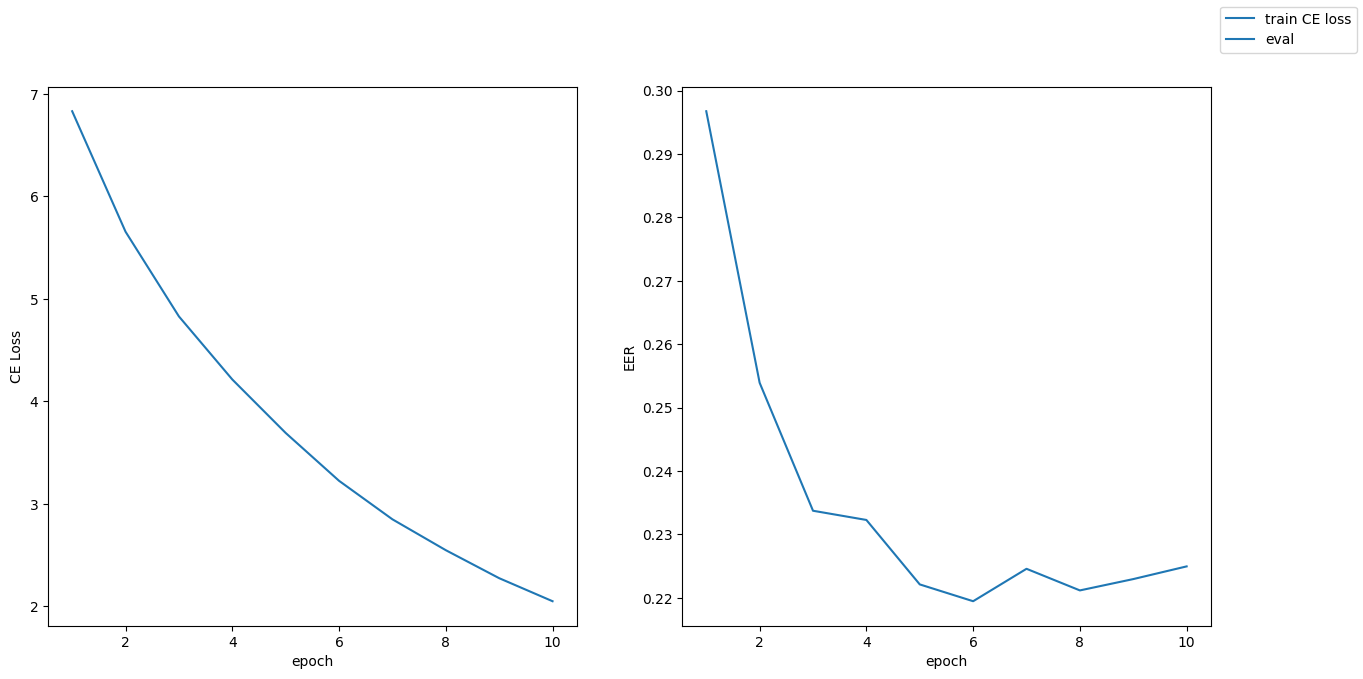

Epoch 10. Train loss 2.0509731346706173. Eval score 0.22496527339310518


In [25]:
model = Model(FEATS, trainset.speakers(), 128).to(DEVICE)
opt = optim.Adam(model.parameters())
train(model, opt)

### ECAPA TDNN (10 points)

Paper: https://arxiv.org/pdf/2005.07143.pdf

Papers for ECAPA parts:
- SE-Blocks - https://arxiv.org/pdf/1709.01507.pdf
- Res2Net - https://arxiv.org/pdf/1904.01169.pdf
- Attentive Stats Pooling - https://arxiv.org/pdf/1803.10963.pdf
- AAM Softmax - https://arxiv.org/pdf/1906.07317.pdf

Also you can optionally add other settings for paper:
- SpecAug
- Weight decay for optimizer
- LR scheduler

In [11]:
'''
we can think of it like residual connection type thing

it allows a network to chose what is important

X -> small X -> Relu (to switch off the unnexessary, 0 or 1) -> back to X -> new_X * X (remember we did relu so unnecessary is 0 now)
'''

class SEBlock(nn.Module):
    def __init__(self, input_shape: int, reduction: int):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(input_shape, input_shape // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(input_shape // reduction, input_shape, bias=False),
            nn.Sigmoid()
        )

    def forward(self, X): 
        b, c, t = X.size() 
        y = self.avg_pool(X).view(b, c)
        y = self.fc(y).view(b, c, 1) 
        return X * y.expand_as(X)

In [12]:
'''
paper summry why we need it.

so, in standart conv consecutive layers we get the local patterns only, we cannot see the table and a pencil on it simultanously

with several cnn's staircase we maek it possible (this is very short example)
'''
class Res2Net(nn.Module):
    def __init__(self, hidden: int, dilation: int, scale: int):
        super().__init__()
        assert hidden % scale == 0, "Hidden channels must be divisible by scale"
        
        self.width = hidden // scale
        self.scale = scale

        self.convs = nn.ModuleList([
            nn.Conv1d(
                self.width, self.width, 
                kernel_size=3, 
                stride=1, 
                padding=dilation, # Padding must match dilation to keep spatial size
                dilation=dilation, 
                bias=False
            ) for _ in range(scale - 1) # skip x1 as in paper so scale - 1
        ])
        
        self.bns = nn.ModuleList([nn.BatchNorm1d(self.width) for _ in range(scale - 1)])
        self.relu = nn.ReLU(inplace=True)

    def forward(self, X):
        # divide into scale (4) chunks
        xs = torch.chunk(X, self.scale, dim=1)
        ys = []

        for i in range(self.scale):
            if i == 0:
                # The first chunk is passed through directly (standard)
                ys.append(xs[i])
            elif i == 1:
                # The second chunk goes through the first conv
                ys.append(self.relu(self.bns[i-1](self.convs[i-1](xs[i]))))
            else:
                # The 'Staircase': current chunk + previous output
                # This is the hierarchical feature fusion
                combined = xs[i] + ys[-1]
                ys.append(self.relu(self.bns[i-1](self.convs[i-1](combined))))
        
        # Concatenate back to the original 'hidden' dimension
        return torch.cat(ys, dim=1)

In [13]:
class EcapaBlock(nn.Module):
    def __init__(self, hidden: int, dilation: int, scale: int):
        super().__init__()
        self.conv1 = nn.Conv1d(hidden, hidden, kernel_size=1)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.res2net = Res2Net(hidden, dilation, scale) 
        self.conv3 = nn.Conv1d(hidden, hidden, kernel_size=1)
        self.bn3 = nn.BatchNorm1d(hidden)
        self.se = SEBlock(hidden, 8) 
        self.relu = nn.ReLU()

    def forward(self, X):
        residual = X
        out = self.relu(self.bn1(self.conv1(X)))
        out = self.res2net(out)
        out = self.bn3(self.conv3(out))
        out = self.se(out)
        return self.relu(out + residual)

In [14]:
'''
This is Context-Aware Attention. By giving the attention layer the global mean and std, you are telling the model: 
"Here is the current frame, and here is what the entire clip looks like on average."

so this is like making a model able to distinguish between noise and actual voice (image)
'''

class AttentiveStatsPooling(nn.Module):
    def __init__(self, input_shape: int, hidden: int):
        super().__init__()
        # The attention layer sees [feats * 3] because we concat X, mean, and std
        self.attention = nn.Sequential(
            nn.Conv1d(input_shape * 3, hidden, kernel_size=1), # as we use karnel=1 it is basically linear layer
            nn.Tanh(),
            nn.Conv1d(hidden, input_shape, kernel_size=1), 
            nn.Softmax(dim=2)
        )

    def forward(self, X):
        mean = torch.mean(X, dim=2, keepdim=True)         # [B, feats, 1]
        std = torch.std(X, dim=2, keepdim=True) + 1e-9    # [B, feats, 1]
        
        mean_ext = mean.expand_as(X)
        std_ext = std.expand_as(X)
        
        # [B, feats * 3, time]
        X_extended = torch.cat([X, mean_ext, std_ext], dim=1)
        alpha = self.attention(X_extended)
        
        weighted_mean = torch.sum(alpha * X, dim=2)

        weighted_var = torch.sum(alpha * (X**2), dim=2) - (weighted_mean**2)
        weighted_std = torch.sqrt(weighted_var.clamp(min=1e-9))

        return torch.cat([weighted_mean, weighted_std], dim=1)

In [15]:
'''
Simple explanation (as I understood)

simple softmax is like this
if ouptut is even a little closer to the target than other (it is ok, you did good job!)

AAM softmax (s, m)

s * cos(0+m) <- formula

1 first normalize the input and weights (they are now -1, 1)
2 we add margin (usually 0<m<1) this tells the loss if the model prediction should be correct even if the target is pushed away by m, should be closer to target rather than other labels even if pushed by m
while scale (s, usisually 30-64) is needed to group the answers into a very tight classes (better in inference scenarios)

you can observer this behaviour there -> https://github.com/happynear/AMSoftmax (some guy made visualization)
'''
class AAMSoftmax(nn.Module):
    def __init__(self, input_shape, n_class, margin=0.5, scale=30.0):
        super().__init__()
        self.input_shape = input_shape
        self.n_class = n_class
        self.margin = margin
        self.scale = scale

        self.weight = nn.Parameter(torch.FloatTensor(n_class, input_shape))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, labels):
        # 1. Normalize X and Weights to project them onto the unit sphere
        cosine = F.linear(F.normalize(X), F.normalize(self.weight))
        theta = torch.acos(cosine.clamp(-1.0 + 1e-7, 1.0 - 1e-7))
        
        # 2. Apply the Additive Angular Margin (theta + m)
        # we only apply this to the target index onlly
        m_cosine = torch.cos(theta + self.margin)
        
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)
        
        # for target class: s * cos(theta + m)
        # for other classes: s * cos(theta)
        logits = (one_hot * m_cosine) + ((1.0 - one_hot) * cosine)
        logits *= self.scale
        
        return F.log_softmax(logits, dim=1)



In [16]:
class EcapaTDNN(nn.Module):
    def __init__(self, input_size: int, output_size: int, hidden_size: int = 512):
        super().__init__()
        self.hidden = hidden_size

        self.layer1 = nn.Sequential(
            nn.Conv1d(input_size, self.hidden, kernel_size=5, padding=2),
            nn.BatchNorm1d(self.hidden),
            nn.ReLU()
        )

        self.block1 = EcapaBlock(self.hidden, dilation=1, scale=8)
        self.block2 = EcapaBlock(self.hidden, dilation=2, scale=8)
        self.block3 = EcapaBlock(self.hidden, dilation=3, scale=8)

        self.conv_agg = nn.Sequential(
            nn.Conv1d(self.hidden * 3, 1536, kernel_size=1),
            nn.ReLU()
        )

        self.asp = AttentiveStatsPooling(1536, hidden=128)
        self.asp_bn = nn.BatchNorm1d(1536 * 2)

        self.fc_emb = nn.Linear(1536 * 2, 192) 
        self.bn_emb = nn.BatchNorm1d(192)

        self.classifier = AAMSoftmax(input_shape=192, n_class=output_size, margin=0.5, scale=30.0)

    def forward(self, X, labels=None) -> tuple[torch.Tensor, torch.Tensor]:
        # --- Feature Extraction ---
        x1 = self.layer1(X)
        x2 = self.block1(x1)
        x3 = self.block2(x2)
        x4 = self.block3(x3)

        x_agg = torch.cat([x2, x3, x4], dim=1)
        x_agg = self.conv_agg(x_agg)

        x_pooled = self.asp(x_agg)
        x_pooled = self.asp_bn(x_pooled)

        emb = self.bn_emb(self.fc_emb(x_pooled))

        if labels is not None:
            logits = self.classifier(emb, labels)
        else:
            logits = F.linear(F.normalize(emb), F.normalize(self.classifier.weight))
            logits = F.log_softmax(logits * self.classifier.scale, dim=-1)

        return logits, emb

Train ECAPA model, at this point you can archive stable score (for several consecutive epochs) near 0.08 EER.

You can train ECAPA with hidden size 256 to increase speed

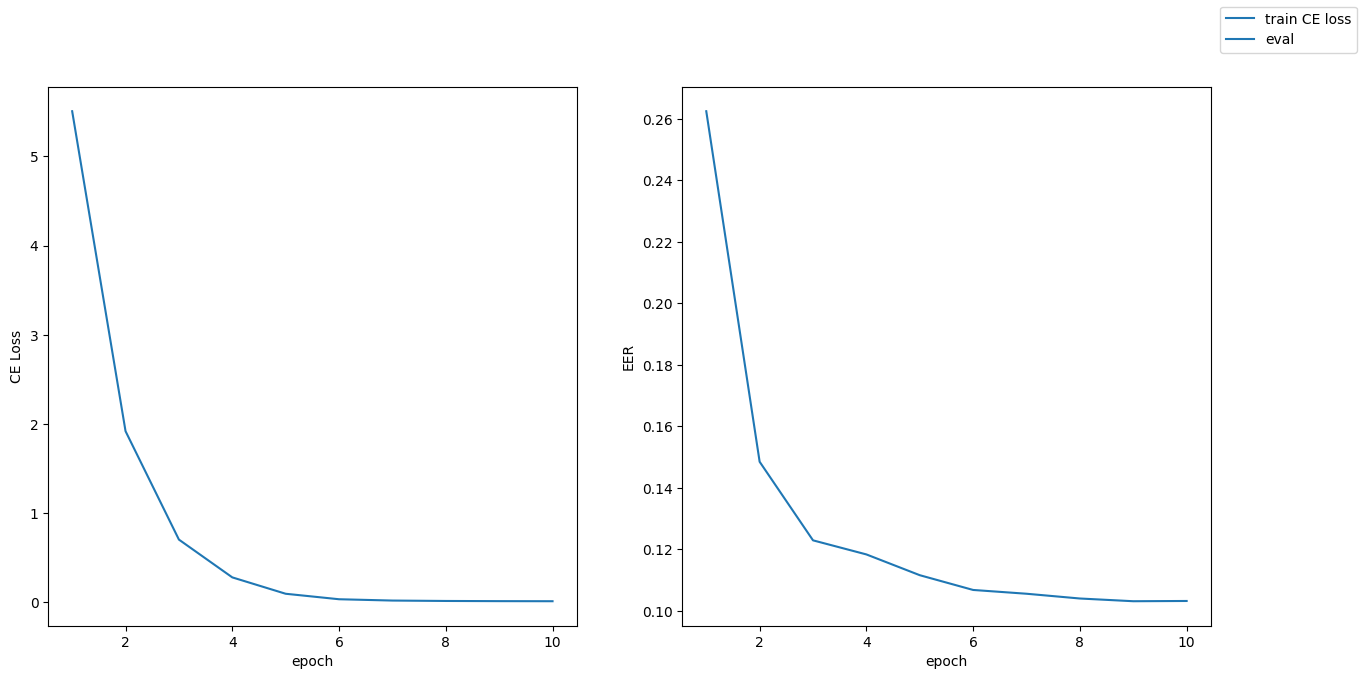

Epoch 10. Train loss 0.013758287801987158. Eval score 0.1032487761459724


In [19]:
model = EcapaTDNN(FEATS, trainset.speakers(), 256).to(DEVICE) # original ECAPA_TDNN uses 1024 hidden size and 3 SE Res2Net blocks and SE reduction=8
opt = optim.Adam(model.parameters())
train(model, opt, batch_size=128, epochs=10)

In [18]:
# Save model to preserve results before uptraining experiments
# torch.save(model, 'model.pt')

### THE FOLLOWING IS FOR 128 HIDDEN SIZE  changed reduction 16->8 and added warmup+cosine decay###
'''
0.1 limit I do not know what is wrong
'''

### THE FOLLOWING IS FOR 512 HIDDEN SIZE ###
'''
scre 0.97 better than 256 model_d but still not 0.08, it seems that it is the architectural flaw.
'''

### THE FOLLOWING IS FOR 256 HIDDEN SIZE ###
'''
the training failed, at 0.1 not reaching targetted 0.08, I will try to reach 0.08-0.06 with the contransive loss below.
probably the readon for fail was hyperparams misconfiguration (mainly bacth size and learning rate 'warmup - cosine decay')
'''

### Contrastive losses (10 points)

You can use anyone constrative loss.
Good article with contrastive losses https://lilianweng.github.io/posts/2021-05-31-contrastive/

Base losses:
- contrastive
- triplet -- it gives a better quality usually
- lifted structured loss -- better batch data utilization

The main problem with contrastive loss is the positive pairs sampler.
This is because a large number of classes provided only once per batch
in case of large number of classes in the dataset.

In [20]:
from collections import defaultdict
import random

class PositivePairsSampler(torch.utils.data.Sampler):
    def __init__(self, speakers: list[int], batch_size: int, samples_per_speaker: int = 4):
        self.speakers_list = np.array(speakers)
        self.batch_size = batch_size
        self.samples_per_speaker = samples_per_speaker
        
        # Create a mapping from speaker_id to list of indices in the dataset
        self.speaker_to_indices = defaultdict(list)
        for idx, speaker_id in enumerate(speakers):
            self.speaker_to_indices[speaker_id].append(idx)
            
        self.unique_speakers = list(self.speaker_to_indices.keys())
        # how many speakers we need per batch
        self.num_speakers_per_batch = batch_size // samples_per_speaker

    def __len__(self):
        return len(self.speakers_list) // self.batch_size

    def __iter__(self):
        for _ in range(len(self)):
            batch_indices = []
            # Randomly select speakers for batch
            selected_speakers = random.sample(self.unique_speakers, self.num_speakers_per_batch)
            
            for spk in selected_speakers:
                indices = self.speaker_to_indices[spk]
                # If speaker has fewer samples than requested, use replacement; else no replacement
                replace = len(indices) < self.samples_per_speaker
                sel_indices = np.random.choice(indices, self.samples_per_speaker, replace=replace)
                batch_indices.extend(sel_indices.tolist())
            
            # shuffle
            random.shuffle(batch_indices)
            yield batch_indices

In [24]:
import torch.nn.functional as F

def contrastive_train_stage(model, opt, scheduler, batch_size: int = 256):
    triplet_loss_fn = torch.nn.TripletMarginLoss(margin=1.0, p=2)

    sampler = PositivePairsSampler(trainset._speakers, batch_size, samples_per_speaker=4)
    loader = torch.utils.data.DataLoader(
        trainset,
        batch_sampler=sampler,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS
    )

    model.train()
    loss_sum = 0.0
    batches = 0
    
    for X, Y, _ in tqdm.tqdm(loader, desc="Batch Hard Training"):
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        
        logits, embeddings = model.forward(X)
        
        # 1. (Cross Entropy)
        cls_loss = F.nll_loss(logits, Y)
        
        # 2. Batch Hard Triplet Selection
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)
        
        mask_pos = (Y.unsqueeze(0) == Y.unsqueeze(1)).float()
        mask_neg = (Y.unsqueeze(0) != Y.unsqueeze(1)).float()

        hardest_pos_dist = (dist_matrix * mask_pos).max(dim=1)[0]

        hardest_neg_dist = (dist_matrix + (1 - mask_neg) * 1e6).min(dim=1)[0]
        
        # Triplet loss = max(0, dist(A,P) - dist(A,N) + margin)
        triplet_loss = torch.clamp(hardest_pos_dist - hardest_neg_dist + 1.0, min=0.0).mean()

        loss = cls_loss + triplet_loss
        
        loss_sum += loss.item()
        batches += 1
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()
        
    return loss_sum / batches

Train model with contrastive loss here. At this point you can archive EER near 0.06-0.07 (it should be at least on 0.005 to 0.01 better than before)

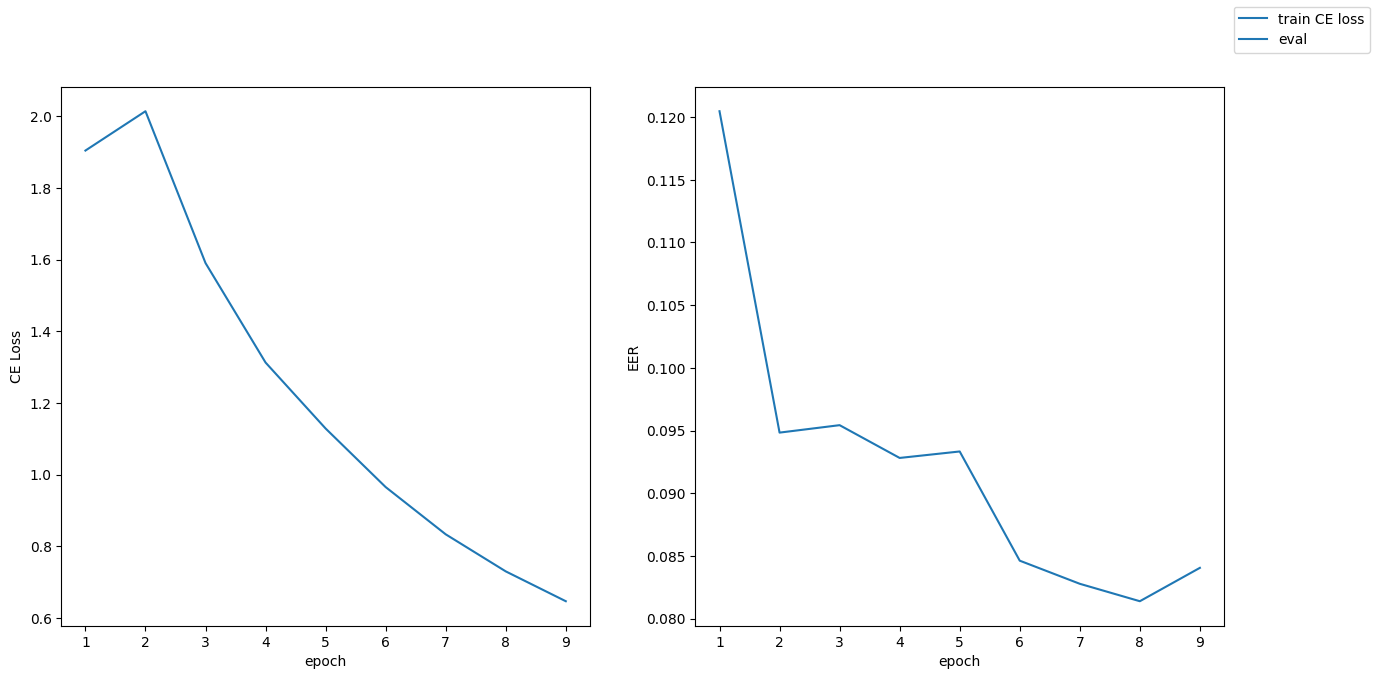

Epoch 9. Train loss 0.6465821338422371. Eval score 0.08404857270010808


Batch Hard Training:   0%|          | 0/264 [00:00<?, ?it/s]

In [ ]:
# model = torch.load('model.pt').to(DEVICE) <- no need to load as we already have it in memory
opt = optim.Adam(model.parameters())
train(model, opt, batch_size=256, train_fun=contrastive_train_stage)

In [ ]:
### THE FOLLOWING IS FOR 128 HIDDEN SIZE  changed reduction 16->8 and added warmup+cosine decay###
'''
ERR of 0.08 (as required 0.01< less than the original)

I think lr tuning also was required, as we see in the beginning 1 epoch was good (sharp decline) but 2 epoch was destructive (spike).
so instead of relying on base 0.001, especially for constrantive loss after large pretraining. Nonetheless, results are good ;)s
'''

### THE FOLLOWING IS FOR 512 HIDDEN SIZE ###
'''
reached 0.9 still not good enough
'''

### THE FOLLOWING IS FOR 256 HIDDEN SIZE ###
'''
the best score was 0.9 ~ I do not know what was wrong this time
'''